# Linear Regression on Kaggle's Car Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import dataset
df = pd.read_csv('../datasets/cardataset.csv')
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
4414,Mitsubishi,Expo,1993,regular unleaded,136.0,4.0,MANUAL,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,26,19,436,2000
3707,Mercedes-Benz,E-Class,2017,premium unleaded (required),329.0,6.0,AUTOMATIC,rear wheel drive,2.0,"Luxury,Performance",Midsize,Convertible,29,20,617,62600
4906,Land Rover,Freelander,2003,regular unleaded,174.0,6.0,AUTOMATIC,all wheel drive,2.0,"Crossover,Luxury",Compact,2dr SUV,19,15,258,26370
6547,Chevrolet,Lumina Minivan,1994,regular unleaded,120.0,6.0,AUTOMATIC,front wheel drive,3.0,NaN,Compact,Passenger Minivan,21,17,1385,2000
2584,Honda,Civic,2016,regular unleaded,174.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,42,31,2202,24700


## Exploratory Data Analysis

In [3]:
# number of rows in the dataset
len(df)

11914

In [4]:
# lowercase all column names, and replace space in column names with underscore
df.columns = df.columns.str.lower().str.replace(" ","_")

In [5]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
# Find columns with text values
string_columns = list(df.select_dtypes(include=['object']).columns)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(" ","_")

C:\Users\gupta\AppData\Local\Temp\ipykernel_41908\3511654387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = list(df.select_dtypes(include=['object']).columns)


In [7]:
df.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [8]:
df = df.dropna()

### Analyze Target Variable

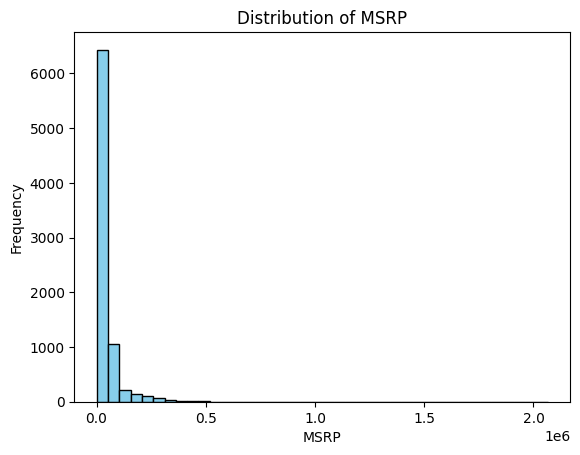

In [9]:
# Analyze target variable: MSRP
plt.hist(df['msrp'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

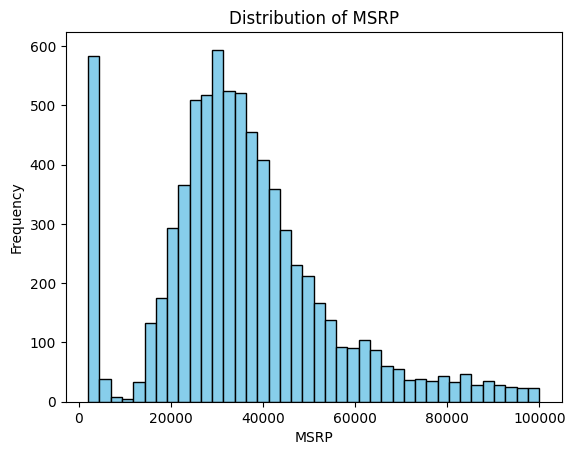

In [10]:
# lot of cars with low prices, and a very long tail
# lets view zoom-in
plt.hist(df.msrp[df.msrp < 100000], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.title('Distribution of MSRP')
plt.show()

### Address Missing Values

In [11]:
df.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

## Setup Validation Framework

In [12]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['msrp'])
# log transformation to address long tail of target variable distribution
y_log = np.log1p(df['msrp'])

X_train, X_test, y_train_log, y_test_log = train_test_split(X,y_log, test_size=0.2, random_state=42)

In [13]:
# view shape of train and test datasets
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train_log.shape}, y_test: {y_test_log.shape}')

X_train: (6467, 15), X_test: (1617, 15), y_train: (6467,), y_test: (1617,)


## One-Hot Encoding

In [14]:
# Initialize one-hot encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [15]:
X_train_encoded_raw = encoder.fit_transform(X_train[string_columns])
X_test_encoded_raw = encoder.transform(X_test[string_columns])

In [16]:
# get new feature names
encoded_col_names = encoder.get_feature_names_out(string_columns)

In [17]:
X_train_encoded_df = pd.DataFrame(X_train_encoded_raw, columns=encoded_col_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded_raw, columns=encoded_col_names,index=X_test.index)

In [18]:
# rejoin and delete originals
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()
X_train_final = pd.concat([X_train[numeric_cols], X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test[numeric_cols], X_test_encoded_df], axis=1)

## Train Linear Regression Model

In [19]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train_final,y_train_log)
coef = regressor.coef_
intercept = regressor.intercept_

## Make Predictions

In [20]:
y_pred_log = regressor.predict(X_test_final)

# undo log transformation
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

## Evaluate the model

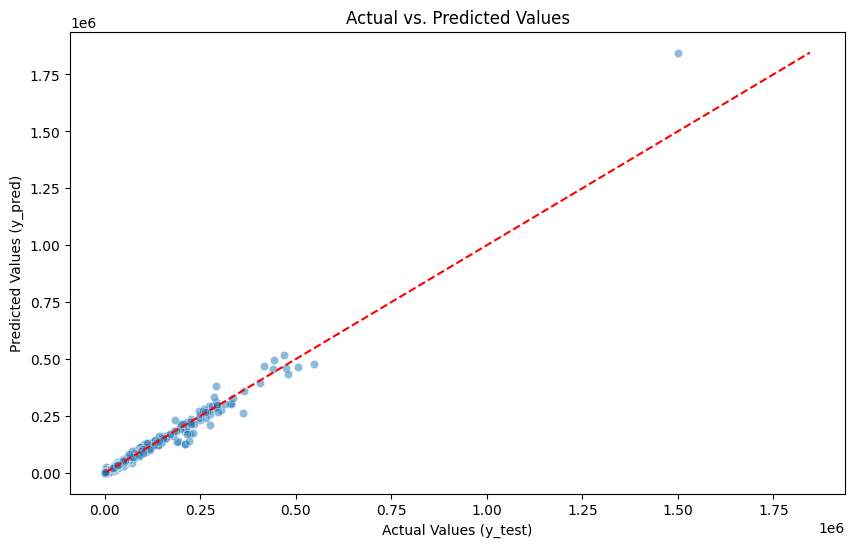

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)

# Add the "Perfect Prediction" line
# This represents where y_test == y_pred
max_val = max(max(y_test_original), max(y_pred_original))
min_val = min(min(y_test_original), min(y_pred_original))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values')
plt.show()

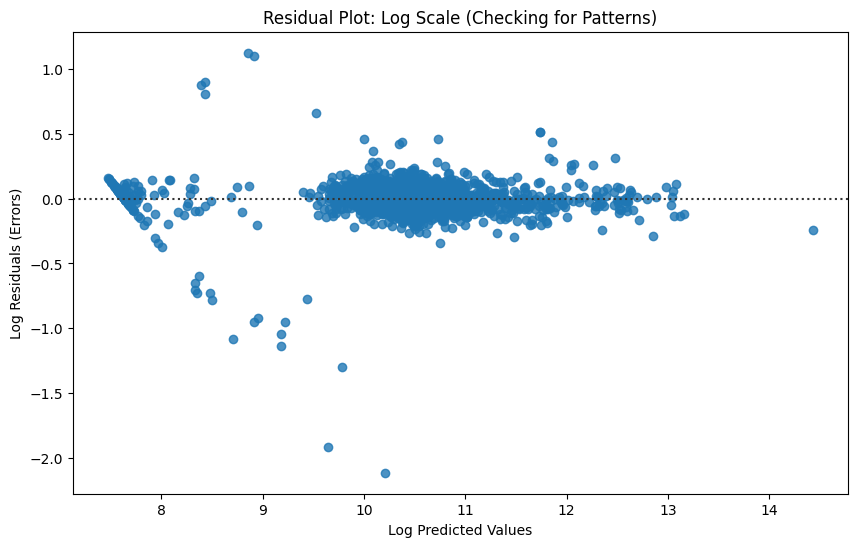

In [30]:
# Residual Plot
# Calculate residuals
residuals = y_test_log - y_pred_log

# --- ADD THIS TO YOUR EVALUATION SECTION ---

# 1. Calculate residuals on the LOG scale
log_residuals = y_test_log - y_pred_log

# 2. Residual Plot on Log Scale
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred_log, y=log_residuals, line_kws={'color': 'red'})
plt.xlabel('Log Predicted Values')
plt.ylabel('Log Residuals (Errors)')
plt.title('Residual Plot: Log Scale (Checking for Patterns)')
plt.show()

We see a tight cluster near zero, but as you move toward predicted values of 250,000 to 500,000, the errors (residuals) flare out significantly. This means the model is much less reliable when predicting higher car prices. A "good" model should show a random cloud of points centered around the horizontal zero line. Your plot shows a distinct pattern where errors become more volatile at higher price points, indicating the model is failing to capture some underlying complexity in the data.

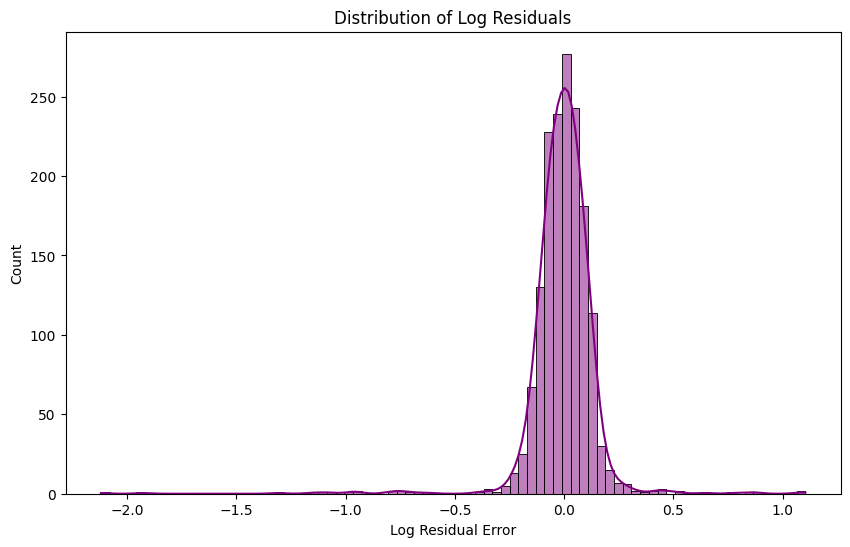

In [31]:
# 3. Distribution of Residuals on Log Scale
plt.figure(figsize=(10, 6))
sns.histplot(log_residuals, kde=True, color='purple')
plt.title('Distribution of Log Residuals')
plt.xlabel('Log Residual Error')
plt.show()

In [32]:
# --- STEP 1: Make Predictions (Model output is on the LOG scale) ---
y_pred_log = regressor.predict(X_test_final)

# --- STEP 2: Undo Log Transformation to get actual Dollar amounts ---
y_pred_dollars = np.expm1(y_pred_log)

# --- STEP 3: (Optional) Compare with actual values in Dollars ---
y_test_dollars = np.expm1(y_test_log)

# Display a sample of the results
results = pd.DataFrame({
    'Actual_MSRP': y_test_dollars,
    'Predicted_MSRP': y_pred_dollars
})
print(results.head())

       Actual_MSRP  Predicted_MSRP
11110      35500.0    34147.194273
2170       29205.0    25616.518070
9785       21215.0    19813.331589
4132       69640.0    68483.684354
11637      51600.0    58998.197433


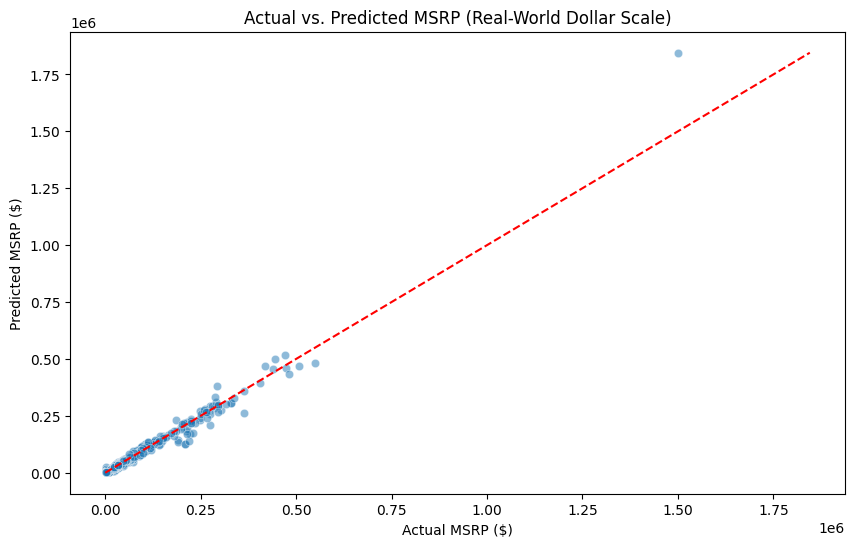

In [34]:
#Actual vs. Predicted Plot (Original Dollar Scale)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)

# Add the "Perfect Prediction" line
max_val = max(y_test_original.max(), y_pred_original.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')

plt.xlabel('Actual MSRP ($)')
plt.ylabel('Predicted MSRP ($)')
plt.title('Actual vs. Predicted MSRP (Real-World Dollar Scale)')
plt.show()